# FEM for submerged tunnel as 3D beams

**Variant met Rayleigh damping C-matrix**

Deze notebook is gebaseerd op `back up_29_5.ipynb`. De globale dempingsmatrix wordt toegevoegd als:

$$C = \alpha M + \beta K$$

waarbij $\alpha$ en $\beta$ worden bepaald uit twee eigenfrequenties en een gekozen dempingsratio.

In [37]:
import numpy as np
import scipy.linalg as scp
import matplotlib.pylab as plt
import time
import os

from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
pass


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


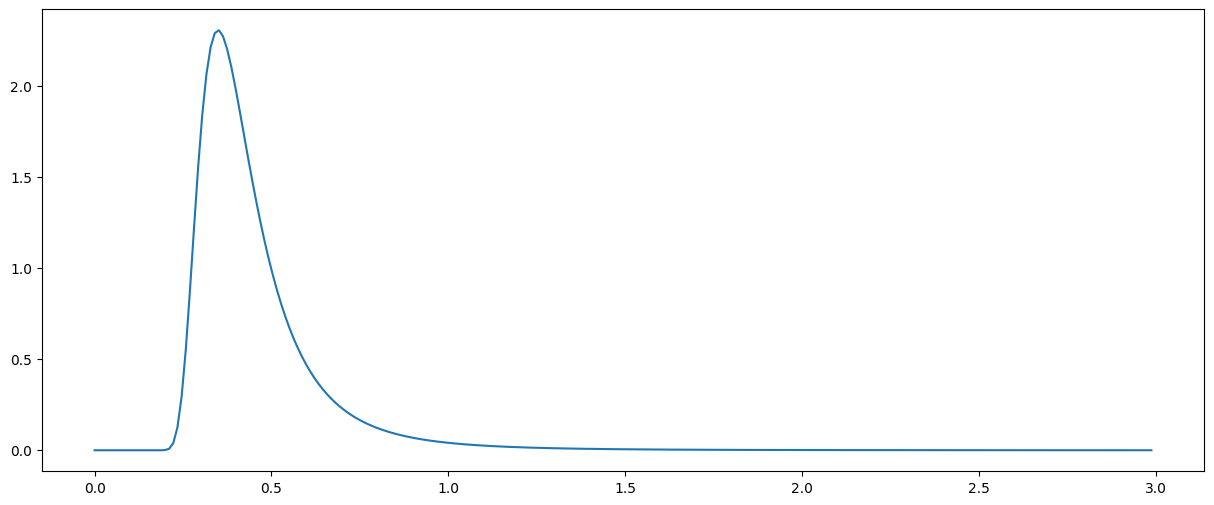

<>:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\Wout-\AppData\Local\Temp\ipykernel_23616\4292758610.py:7: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('$\omega$ (rad/s)')
C:\Users\Wout-\AppData\Local\Temp\ipykernel_23616\4292758610.py:8: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta_0$ (m)')


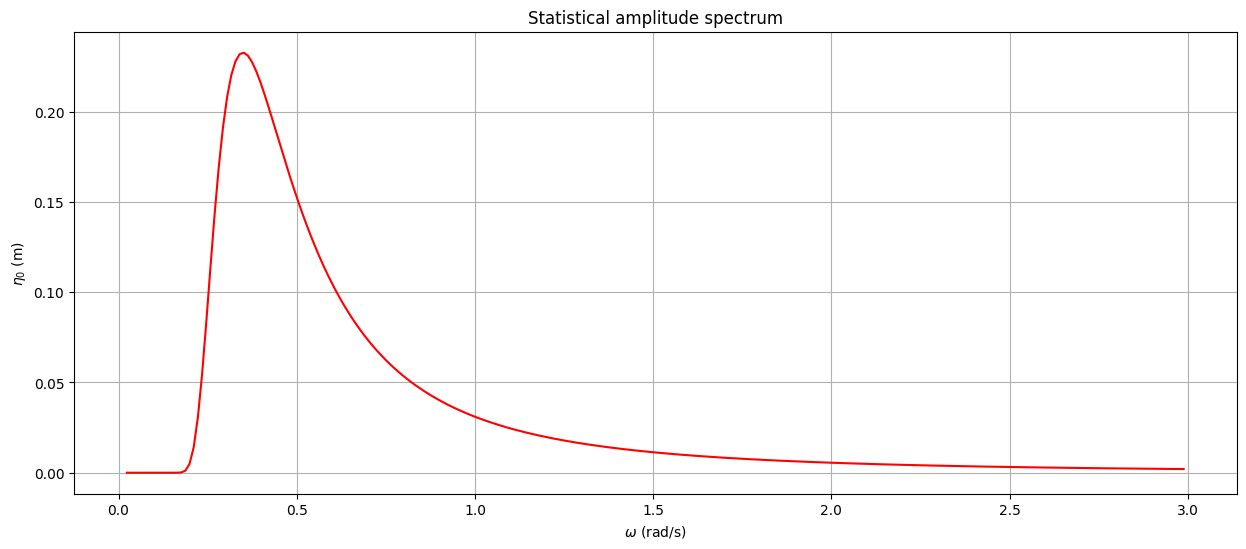

[2.02271242 2.03618922 2.04326959 ... 0.14725903 0.14414017 0.14024623] [0.3881513  0.38624089 0.38367452 ... 0.04680856 0.04550755 0.04431942] [-0.07566047 -0.09106618 -0.10649072 ... -0.06946335 -0.06923338
 -0.06901753] [0.39545662 0.39683129 0.39817887 ... 0.08376275 0.08285046 0.08202214] [-0.01585464 -0.02236941 -0.02897113 ... -0.01358668 -0.01243927
 -0.01133037] [-0.15386383 -0.15420115 -0.1542391  ...  0.00233597  0.00224616
  0.00205403]
1200 dit is de lengte van vx_t
Elapsed time =  8.343047142028809  s


<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\Wout-\AppData\Local\Temp\ipykernel_23616\2442311115.py:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('$\eta$ (m)')
C:\Users\Wout-\AppData\Local\Temp\ipykernel_23616\2442311115.py:23: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  plt.ylabel('$\dot{v}$ (m/s2)')


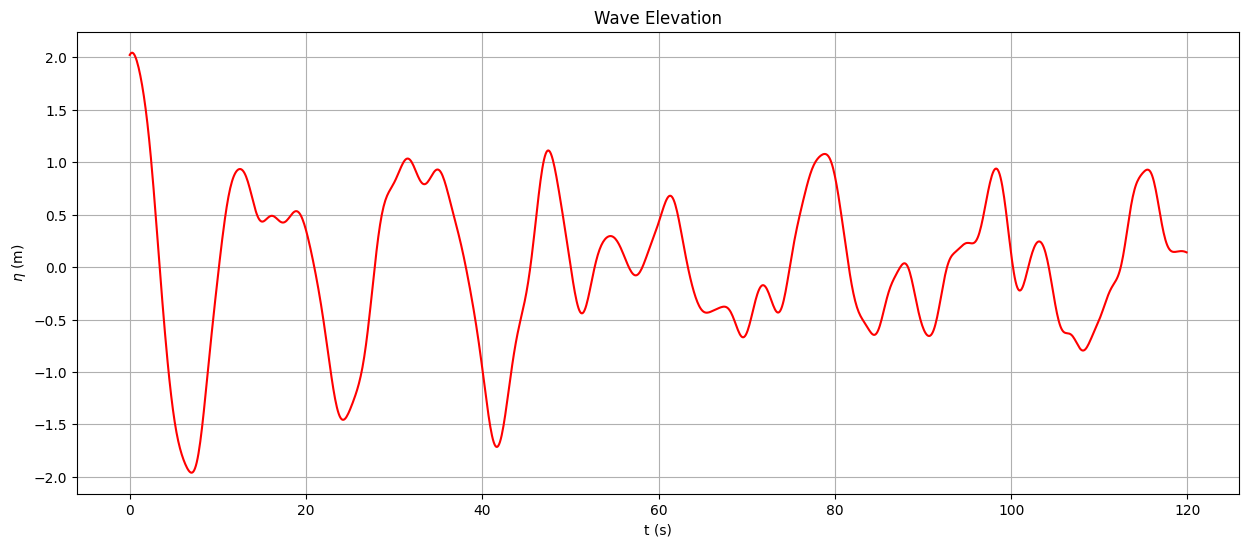

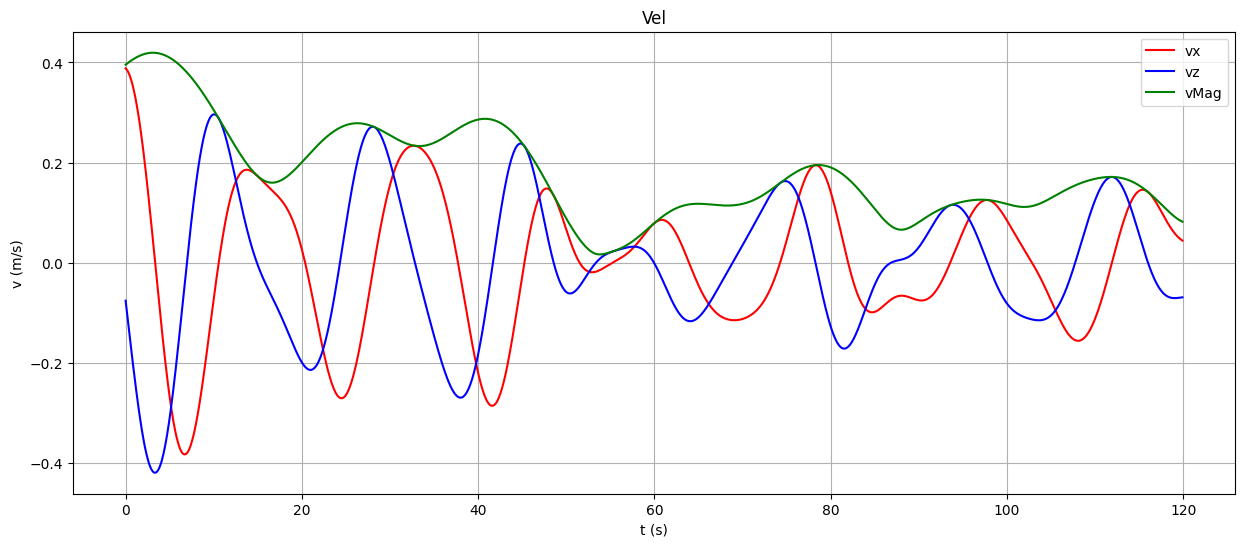

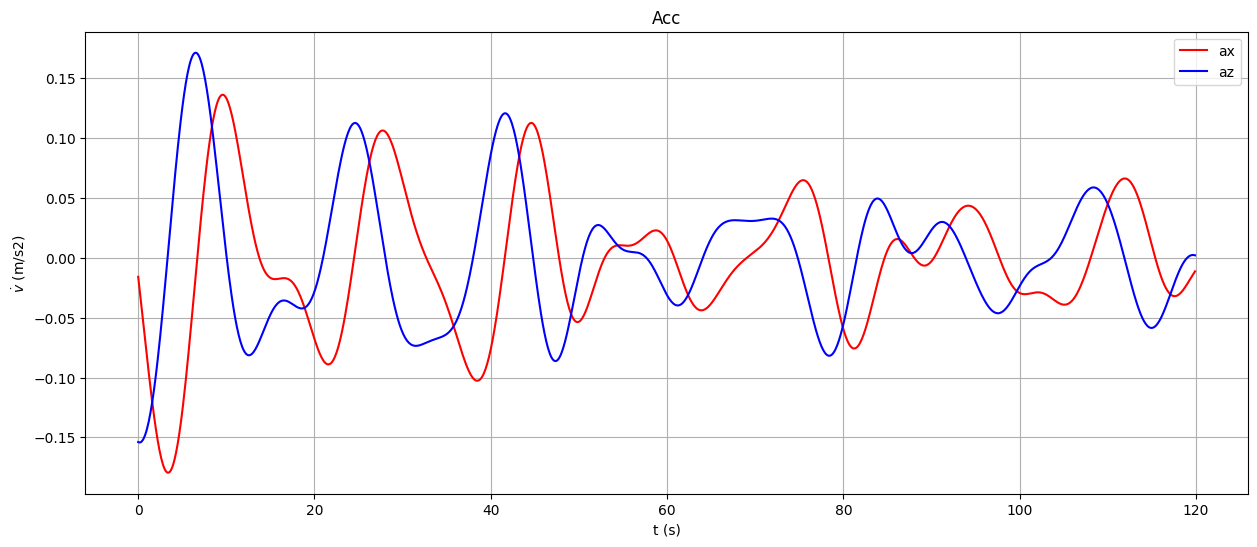

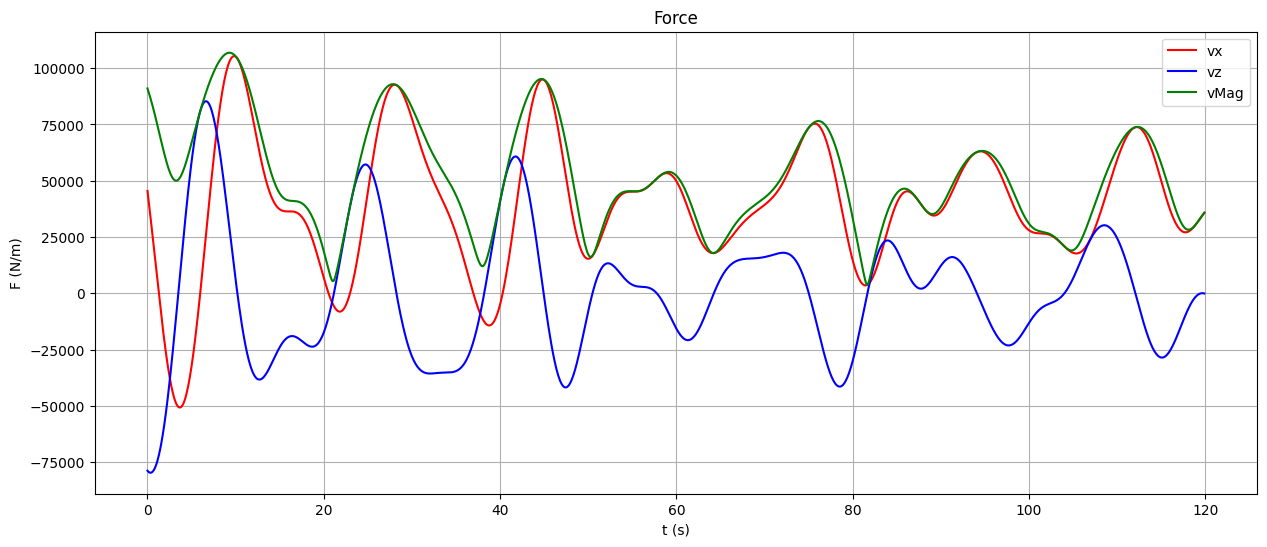

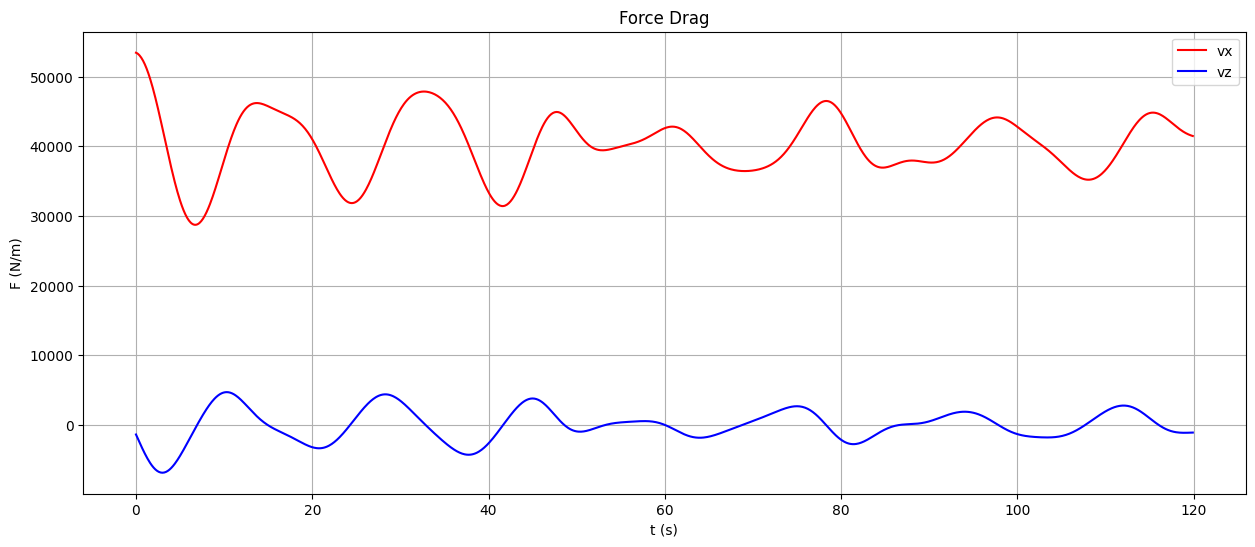

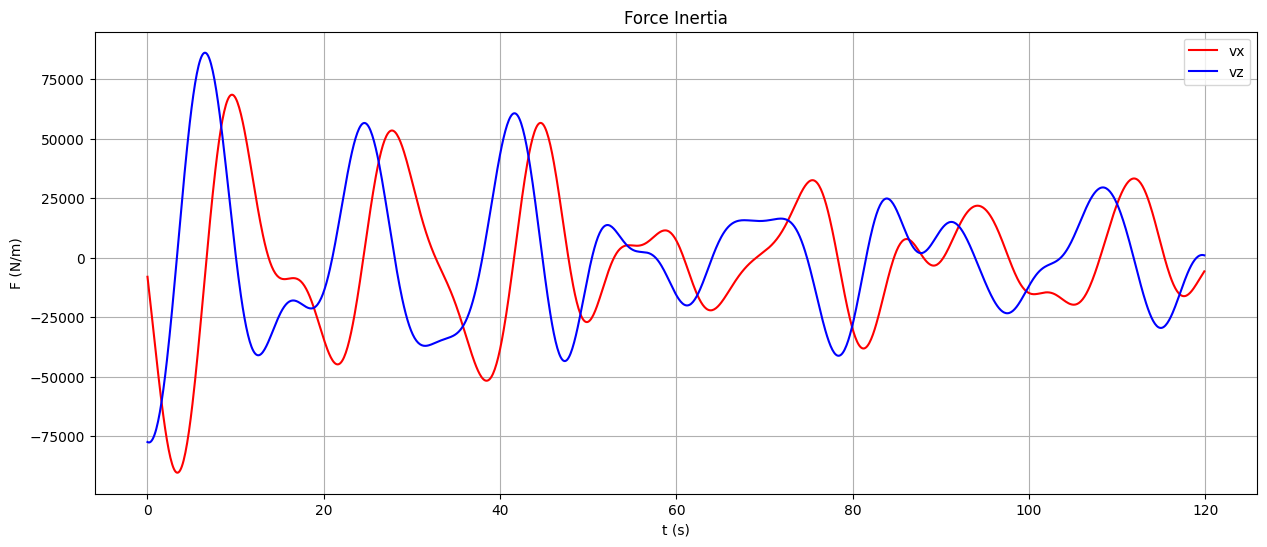

<class 'list'>
<class 'list'>
1200
1200
t: (1200,)
Fx: (1200,)
Fz: (1200,)


In [38]:
# Cell 1 FEM notebook

%run nb02_j_morison.ipynb
print(type(Fx_t))
print(type(Fz_t))
print(len(Fx_t))
print(len(Fz_t))
t_t  = np.asarray(t_t)
Fx_t = np.asarray(Fx_t)
Fz_t = np.asarray(Fz_t)

print("t:", t_t.shape)
print("Fx:", Fx_t.shape)
print("Fz:", Fz_t.shape)

## Visualize the tunnel

- Radius = 2683 m
- Distance between landings = 3700 m
- Angular span = [68.2 deg, 111.8 deg]

Number of nodes (visualize) = 525


Text(0.5, 0.5, 'y (m)')

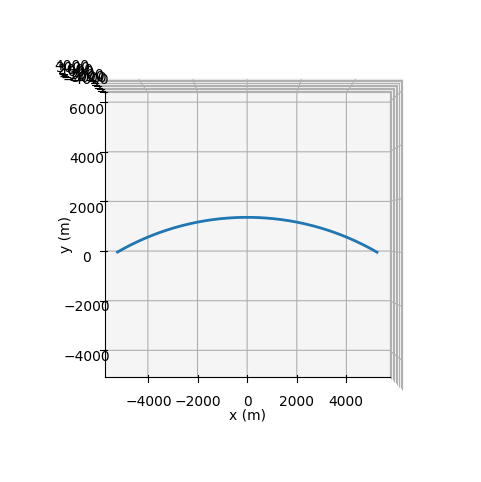

In [39]:
TunRad = 10000 #m
TunAng = (120, 60) #deg
dth = 0.1146 #deg
TunCX = TunRad*np.cos( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunRad*np.sin( np.deg2rad( np.arange(TunAng[0], TunAng[1]-dth, -dth) ) )
TunCY = TunCY - min(TunCY)-15
TunCZ = 0*TunCX
print("Number of nodes (visualize) =", len(TunCX))


ax = plt.axes(projection='3d')
ax.view_init(90, 270)
plt.plot(TunCX, TunCY, TunCZ, lw=2)
# plt.plot(TunCX2, TunCY2, TunCZ2, lw=2)
plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')



## Properties of Beam

In [40]:
Beam_m = 1267 * 2 + 790 + 1025  * (20+8)   # [kg/m]
Beam_EI = 45000000000 * 3712                 # [N.m2]
Beam_EA = 45000000000 * (39.87+39.87+20.45)                # [N]
Beam_GJ = 8.30e13                 # [N.m2]
Beam_Im = 44.16                      #[kg.m]

## Mesh setup

In [41]:
NodeC = [ [x,y,z] for x,y,z in zip(TunCX, TunCY, TunCZ) ]
nNode = len(NodeC)

# Define elements (and their properties
#             NodeLeft    NodeRight          m         EA        EI  GJ  Im
# Tunnel elemenets
Ele = [ [n1, n2, Beam_m, Beam_EA, Beam_EI, Beam_GJ, Beam_Im] 
           for n1,n2 in zip(range(0,nNode-1), range(1,nNode)) ]



nEle = len(Ele)

print("Number of nodes = ",nNode)
print("Number of elements = ",nEle)
# print(NodeC)
print(Ele)

Number of nodes =  525
Number of elements =  524
[[0, 1, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [1, 2, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [2, 3, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [3, 4, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [4, 5, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [5, 6, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [6, 7, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [7, 8, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [8, 9, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [9, 10, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [10, 11, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [11, 12, 32024, 4508550000000.0, 167040000000000, 83000000000000.0, 44.16], [12, 13, 32024, 4508550000000.0, 167040000000000, 8300000

Listing the nodes and elements. <br>
Plot the mesh setup for reference.

Nodes
Elements


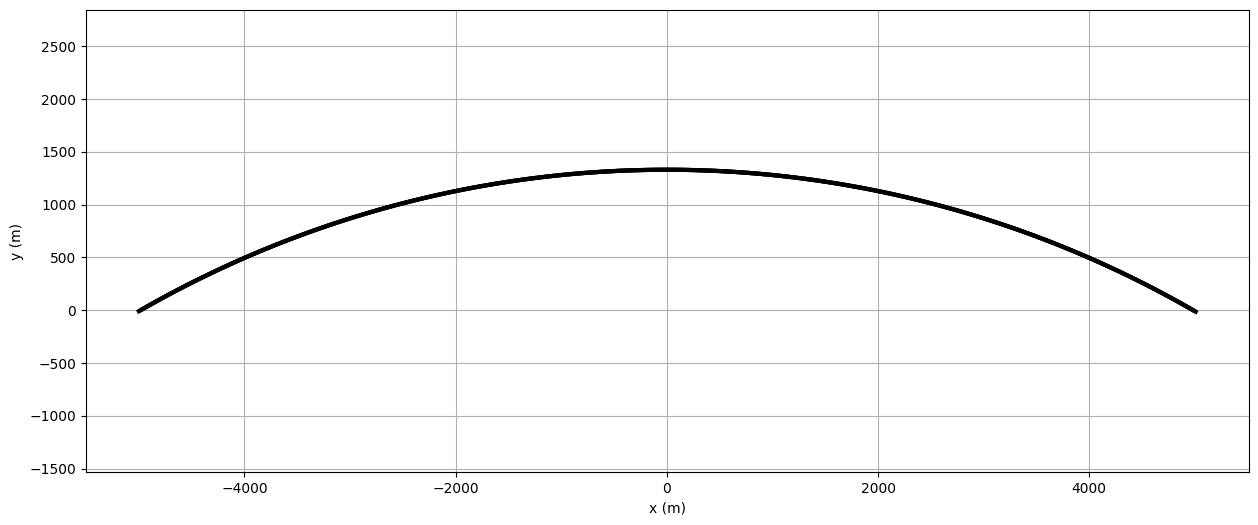

In [42]:
print("Nodes")
# for iNode in range(0, nNode):
#     print(iNode, "\t", NodeC[iNode][0], "\t", NodeC[iNode][1], "\t", NodeC[iNode][2])

plt.figure()
print("Elements")
for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    #print(iEle, n1, n2, m, EA, EI, GJ, Im)    
    plt.plot( [NodeC[n1][0], NodeC[n2][0]], 
             [NodeC[n1][1], NodeC[n2][1]],              
             lw=3, color='k')

plt.grid("on")
plt.axis("equal")
plt.xlabel('x (m)')
plt.ylabel('y (m)')
pass

## Define the shape functions

Here we will use **linear** shape functions for the **axial displacement** and **cubic** shape functions for the **deflection and rotations**. Since we already know its expression and we already have the value of the elemental matrices, we skip this step in this tutorial. 

## Computation of the elemental matrices

In the theory we have seen that the mass and stiffness elemental matrices for the space frame using linear and cubic shape functions are given by:

| <img width="50%" src="./img/nb09_f01_3Ddofs_nptel.png" /> |
| :---- |
| Fig 1: Definition of 3 dofs per node, for the 2 noded elements. (This is from my lectures slides. To Be replaced) |

$$ M = \frac{mL}{420} 
\begin{bmatrix} 
140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 156 & 0 & 0 & 0 & 22L & 0 & 54 & 0 & 0 & 0 & -13L \\ 
0 & 0 & 156 & 0 & 22L & 0 & 0 & 0 & 54 & 0 & 13L & 0 \\ 
0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 & 70 & 0 & 0 \\ 
0 & 0 & 22L & 0 & 4L^2 & 0 & 0 & 0 & -13L & 0 & -3L^2 & 0 \\ 
0 & 22L & 0 & 0 & 0 & 4L^2 & 0 & 13L & 0 & 0 & 0 & -3L^2 \\ 
70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 & 0 & 0 & 0 \\ 
0 & 54 & 0 & 0 & 0 & 13L & 0 & 156 & 0 & 0 & 0 & -22L \\ 
0 & 0 & 54 & 0 & -13L & 0 & 0 & 0 & 156 & 0 & 22L & 0 \\ 
0 & 0 & 0 & 70 & 0 & 0 & 0 & 0 & 0 & 140 & 0 & 0 \\ 
0 & 0 & 13L & 0 & -3L^2 & 0 & 0 & 0 & 22L & 0 & 4L^2 & 0 \\
0 & -13L & 0 & 0 & 0 & -3L^2 & 0 & -22L & 0 & 0 & 0 & 4L^2
\end{bmatrix} $$
$$ \quad K = 
\begin{bmatrix} 
\frac{EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{-EA}{L} &  0 & 0 & 0 & 0 & 0\\ 
0 & \frac{12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{-12EI}{L^3} & 0 & 0 & 0 & \frac{6EI}{L^2} \\ 
0 & 0 & \frac{12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{-12EI}{L^3} & 0 & -\frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & \frac{-6EI}{L^2} & 0 & \frac{4EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L} & 0 & \frac{-6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} \\ 
\frac{-EA}{L} & 0 & 0 & 0 & 0 & 0 & \frac{EA}{L} & 0 & 0 & 0 & 0 & 0 \\ 
0 & -\frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{12EI}{L^3} & 0 & 0 & 0 & -\frac{6EI}{L^2} \\ 
0 & 0 & -\frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{12EI}{L^3} & 0 & \frac{6EI}{L^2} & 0\\ 
0 & 0 & 0 & -\frac{GJ}{L} & 0 & 0 & 0 & 0 & 0 & \frac{GJ}{L} & 0 & 0 \\ 
0 & 0 & -\frac{6EI}{L^2} & 0 & \frac{2EI}{L} & 0 & 0 & 0 & \frac{6EI}{L^2} & 0 & \frac{4EI}{L} & 0 \\ 
0 & \frac{6EI}{L^2} & 0 & 0 & 0 & \frac{2EI}{L} & 0 & -\frac{6EI}{L^2} & 0 & 0 & 0 & \frac{4EI}{L}
\end{bmatrix}$$

These matrices are used directly when calling the `BeamMatrices` function within the assembly process.

## Global assembly

The last step is to compute the global matrices and the global forcing vector. We start by initializing the global matrices as 1-dimensional arrays.

Then we loop over elements and perform all the elemental operations.

In [43]:
LDOF = 6
nDof = LDOF*nNode  # 6 dof per node

# Global matrices as 1D arrays during assembly
K = np.zeros(nDof*nDof)
M = np.zeros(nDof*nDof)
Q = np.zeros(nDof*nDof)
C_element = np.zeros(nDof*nDof)  # optional elemental damping from BeamMatrices.py; usually zero here

# Import the beam element matrices.
# Make sure BeamMatrices.py is in the same folder as this notebook.
from BeamMatrices import Beam3DMatrices

# Additional translational stiffness per node range (local mooring/support stiffness)
# Only translational DOFs [u,v,w] are affected.
# Only even node indices receive stiffness.
node_stiffness = np.zeros((nNode, 3))
for n0 in range(nNode):
    if n0 % 2 != 0:
        continue
    if 0 <= n0 <= 131:
        node_stiffness[n0, :] = [2*1296000, 2*254400000, 2*1296000]
    elif 132 <= n0 <= 184:
        node_stiffness[n0, :] = [2*370000, 2*19900000, 2*370000]
    elif 185 <= n0 <= 341:
        node_stiffness[n0, :] = [2*216000, 2*14100000, 2*216000]
    elif 342 <= n0 <= 367:
        node_stiffness[n0, :] = [2*370000, 2*19900000, 2*370000]
    elif 368 <= n0 <= nNode-1:
        node_stiffness[n0, :] = [2*1296000, 2*254400000, 2*1296000]

exeTime = [0.0, 0.0]
exeTime[0] = time.time()

for iEle in range(0, nEle):
    n1, n2, m, EA, EI, GJ, Im = Ele[iEle]
    n1 = int(round(n1))
    n2 = int(round(n2))
    
    n1dof = LDOF*n1 + np.arange(0, LDOF)
    n2dof = LDOF*n2 + np.arange(0, LDOF)
    indexes = np.append(n1dof, n2dof)
    
    # Calculate elemental matrices.
    # Beam3DMatrices returns: mass, stiffness, wave/force interpolation matrix, elemental damping.
    # In the current BeamMatrices.py, Ce is zero. Rayleigh damping is added after global assembly.
    Me, Ke, Qe, Ce = Beam3DMatrices(m, EA, EI, GJ, Im, (NodeC[n1], NodeC[n2]))

    # Apply local mooring stiffness only to the translational DOFs of node n1.
    # If node n1 has zero stiffness, no mooring stiffness is added for this element.
    K_moor = np.zeros((2*LDOF, 2*LDOF))
    if np.any(node_stiffness[n1]):
        K_moor[0, 0] = node_stiffness[n1, 0]
        K_moor[1, 1] = node_stiffness[n1, 1]
        K_moor[2, 2] = node_stiffness[n1, 2]

    Ke = Ke + K_moor
    
    for i in range(0, 2*LDOF):
        for j in range(0, 2*LDOF):
            ij = indexes[i]*nDof + indexes[j]
            M[ij] = M[ij] + Me[i, j]
            K[ij] = K[ij] + Ke[i, j]
            Q[ij] = Q[ij] + Qe[i, j]
            C_element[ij] = C_element[ij] + Ce[i, j]

# Reshape the global matrices from 1-dimensional arrays to 2-dimensional arrays
M = M.reshape((nDof, nDof))
K = K.reshape((nDof, nDof))
Q = Q.reshape((nDof, nDof))
C_element = C_element.reshape((nDof, nDof))

exeTime[1] = time.time()
print("Execution time = ", exeTime[1] - exeTime[0], "s")
print("Global M shape:", M.shape)
print("Global K shape:", K.shape)
print("Elemental C shape:", C_element.shape, " | non-zero entries:", np.count_nonzero(C_element))

Execution time =  0.28833818435668945 s
Global M shape: (3150, 3150)
Global K shape: (3150, 3150)
Elemental C shape: (3150, 3150)  | non-zero entries: 0


That completes the filling of the matrices. Let's have a look at the matrices' structure.

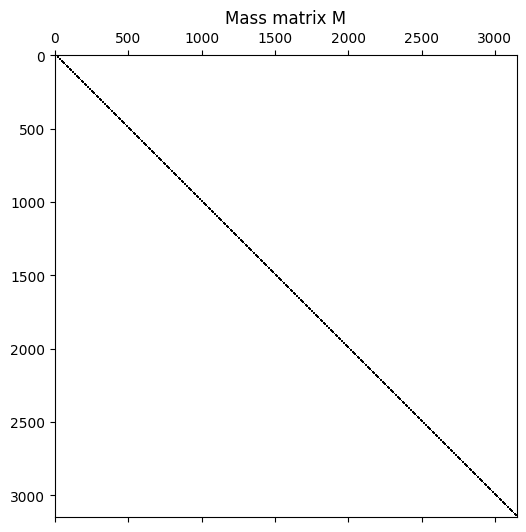

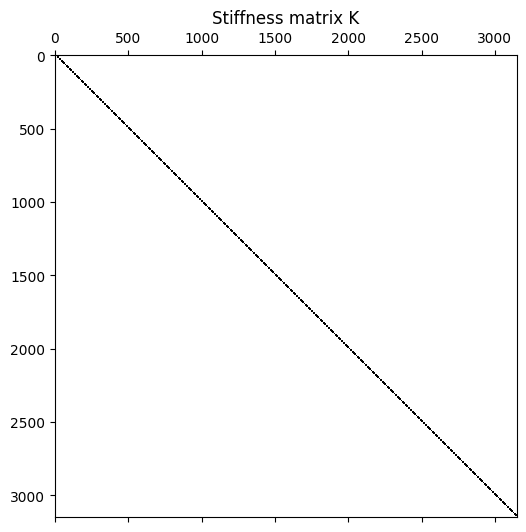

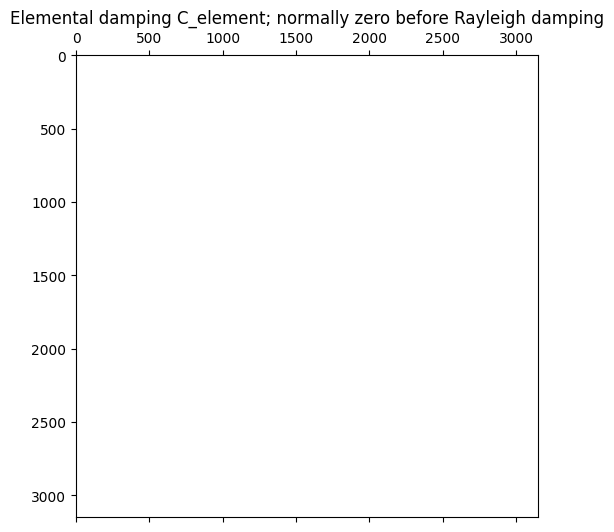

In [44]:
# Look at the matrix structure
plt.figure()
plt.spy(M)
plt.title("Mass matrix M")
plt.figure()
plt.spy(K)
plt.title("Stiffness matrix K")
plt.figure()
plt.spy(C_element)
plt.title("Elemental damping C_element; normally zero before Rayleigh damping")
pass

## Boundary conditions

To apply the boundary conditions we fix all the DOFs for the selected clamped nodes. First we identify the fixed DOFs and then we build the reduced free-DOF matrices.

Number of fixed DOFs: 1104
Number of free DOFs: 2046


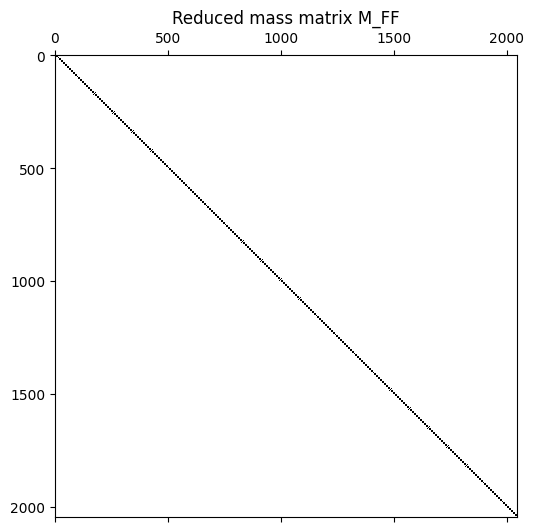

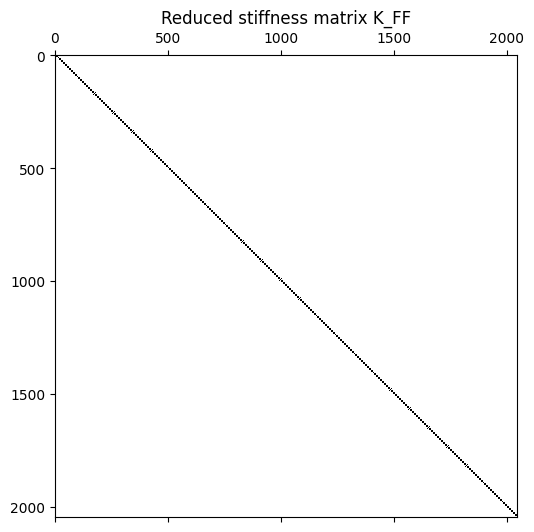

In [ ]:
# Nodes 0-131 and 473-end are clamped in all DOFs.
# We fix the full 6 DOFs for these nodes.
NodesClamp = list(range(0, 132)) + list(range(473, nNode))

# Prescribed dofs: fix DOFs 0..5 for the clamped nodes
DofsP = np.empty([0], dtype=int)
for n0 in NodesClamp:
    DofsP = np.append(DofsP, n0*LDOF + np.arange(0, 6))  # DOF 0..5

# Free dofs
DofsF = np.arange(0, nDof)       # all DOFs
DofsF = np.delete(DofsF, DofsP)  # remove the fixed DOFs

print('Number of fixed DOFs:', len(DofsP))
print('Number of free DOFs:', len(DofsF))

# Reduced free-DOF matrices
M_FF = M[np.ix_(DofsF, DofsF)]
K_FF = K[np.ix_(DofsF, DofsF)]
# Q_FF = Q[np.ix_(DofsF, DofsF)]
# C_element_FF = C_element[np.ix_(DofsF, DofsF)]

plt.figure()
plt.spy(M_FF)
plt.title('Reduced mass matrix M_FF')
plt.figure()
plt.spy(K_FF)
plt.title('Reduced stiffness matrix K_FF')
pass

## Modal analysis

Using the matrices associated to the free DOFs, we can perform a modal analysis to get more information on how the structure will deform and determine the natural frequencies.

$$ ( K_{FF} - \omega^2 M_{FF} ) \phi = 0 $$

To compute the natural frequencies and mode shapes we use the `eig` command, which is part of the NumPy package. For more information see: https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html

In [46]:
# Modal analysis using the generalized eigenvalue problem:
# K_FF phi = omega^2 M_FF phi
# If M_FF is not numerically positive definite, use the general eig solver.
w2, vr = scp.eig(K_FF, M_FF)

# Keep only finite real positive eigenvalues (omega^2)
finite = np.isfinite(w2)
real = np.isreal(w2)
positive = finite & real & (w2.real > 1e-8)
w2 = w2.real[positive]
vr = vr[:, positive]

w = np.sqrt(w2)
f = w/(2*np.pi)
print('Number of positive modes:', len(f))

Number of positive modes: 1863


In [47]:
idx = f.argsort()
f = f[idx]
w = w[idx]
vr = vr[:, idx]

print('First 20 natural frequencies [Hz]:')
print(f[:20])

First 20 natural frequencies [Hz]:
[0.02427633 0.02584123 0.0296758  0.0356883  0.04352671 0.05305328
 0.05967518 0.06355282 0.07048862 0.08090761 0.09261014 0.10620794
 0.1216523  0.13812267 0.15632661 0.1759489  0.19241609 0.19470758
 0.19674855 0.19682956]


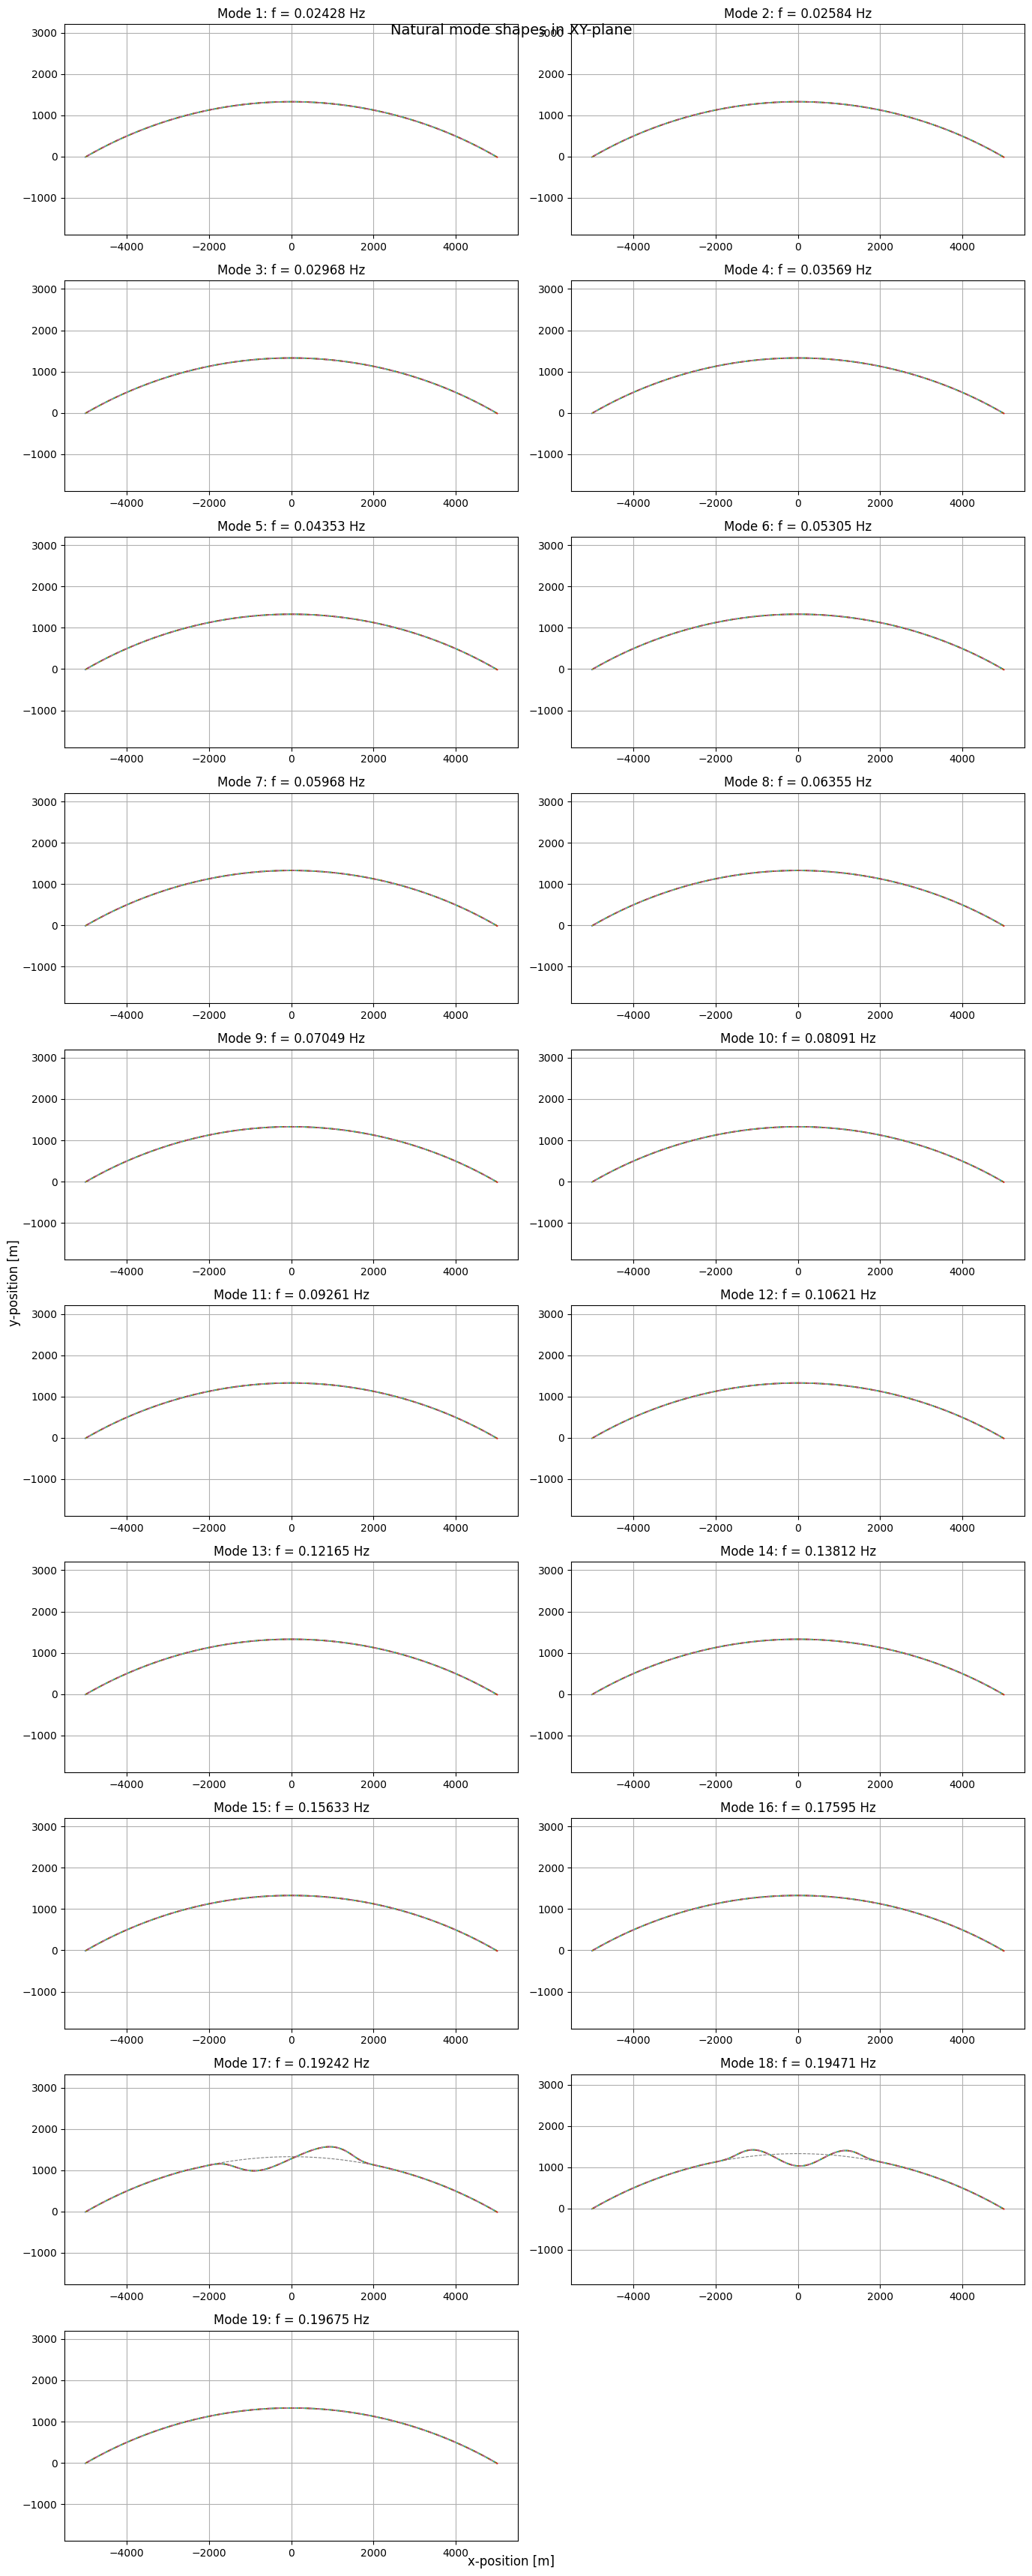

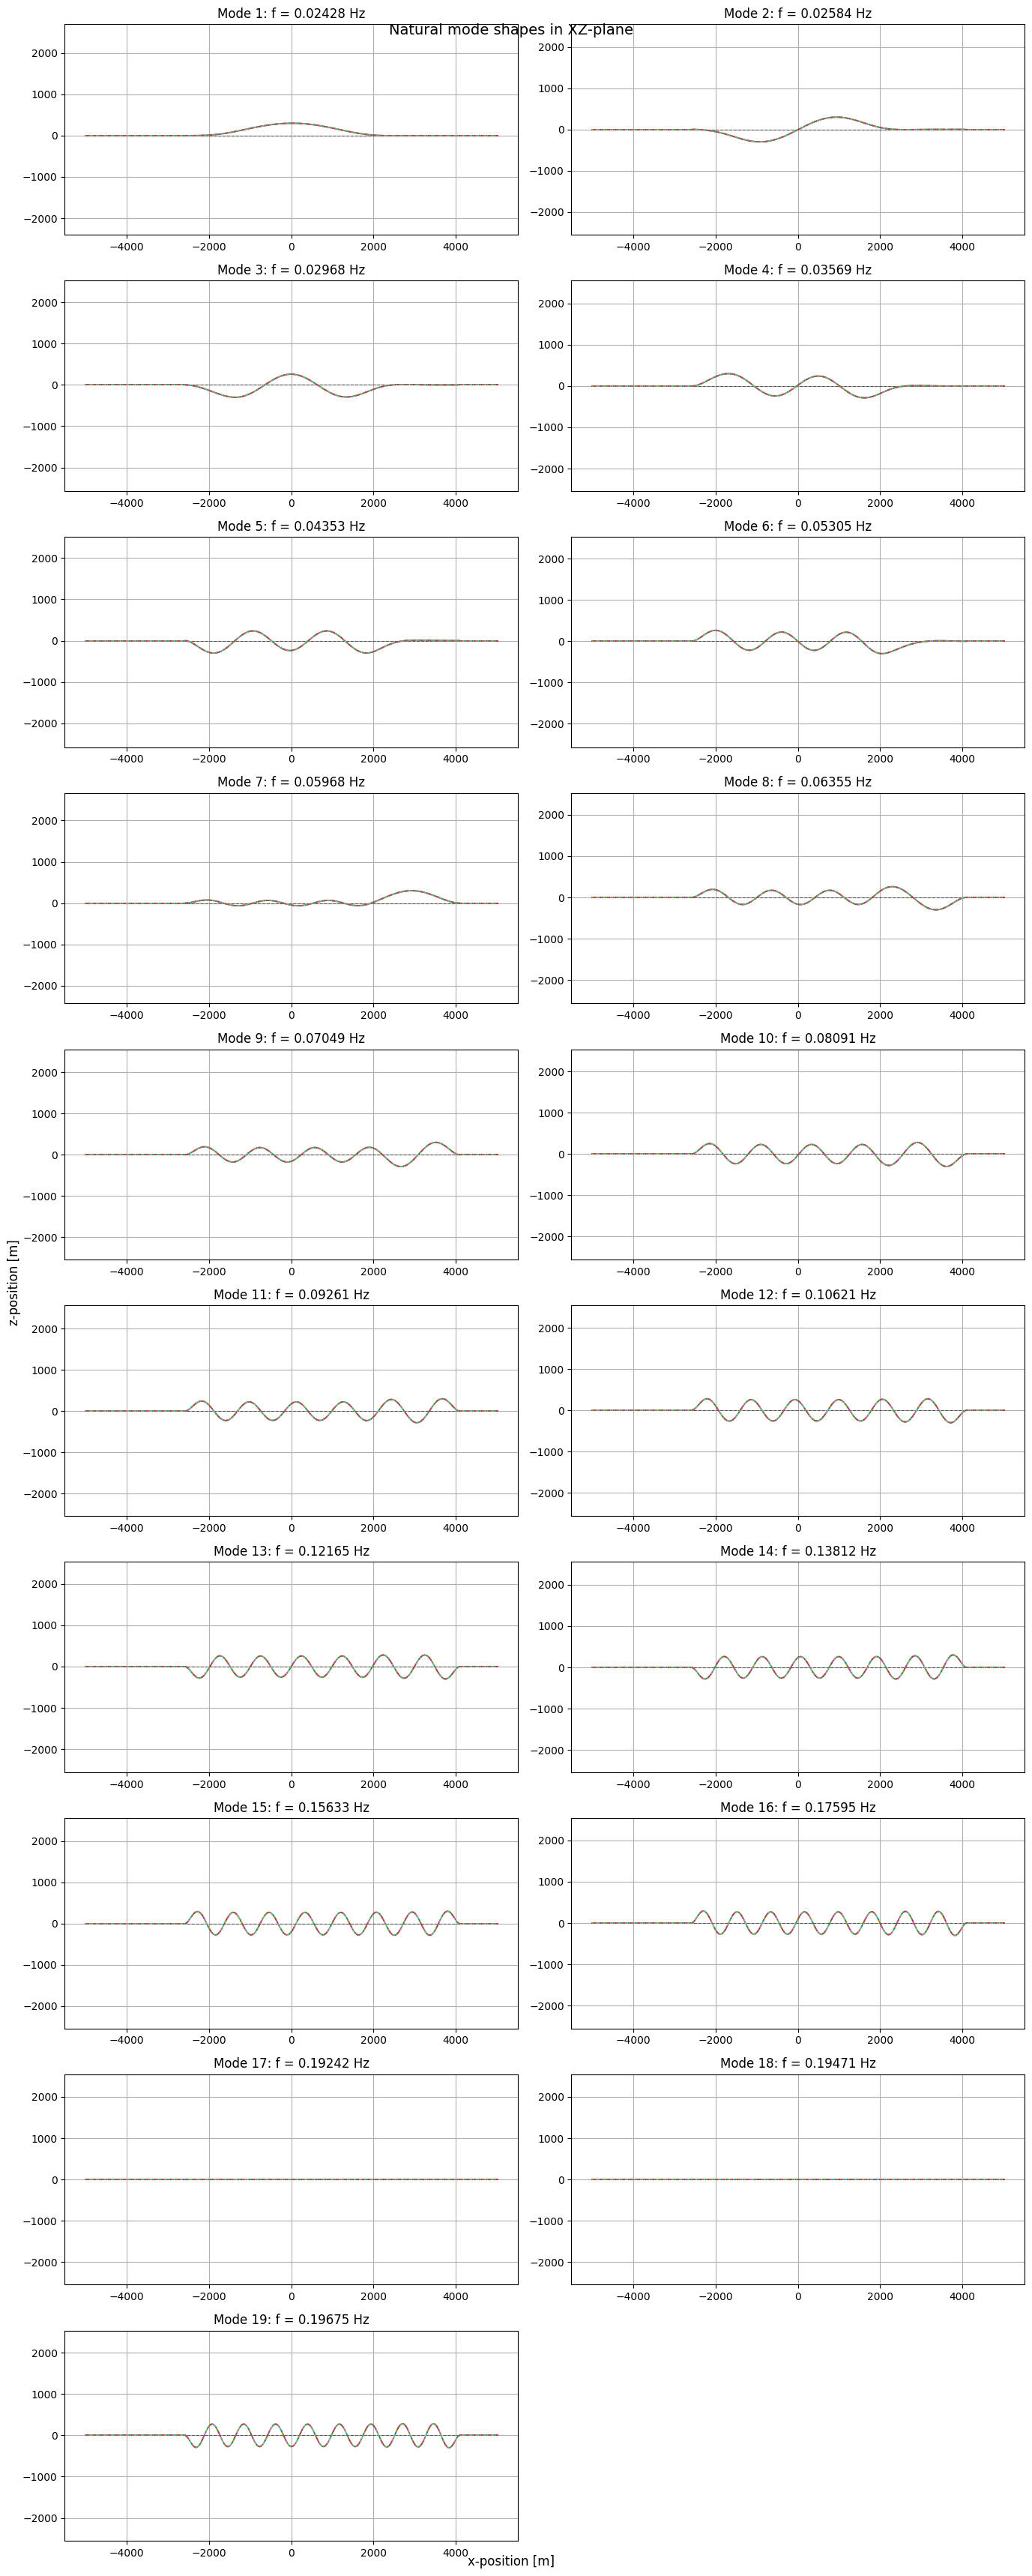

In [48]:
# ============================================================
# Plot first 10 natural mode shapes in XY- and XZ-plane
# Tunnel lies in XY-plane, with out-of-plane Z displacements
# ux = horizontal displacement
# uy = vertical displacement in the tunnel plane
# uz = out-of-plane displacement
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

NodeC_arr = np.asarray(NodeC)

x0 = NodeC_arr[:, 0]
y0 = NodeC_arr[:, 1]
z0 = NodeC_arr[:, 2]

# First 10 modes
modes_to_plot = np.arange(0, 19)

# Prepare modal shape matrix for full DOF plotting
nMode = len(f)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF, :] = vr

# Plot settings
nCol = 2
nRow = int(np.ceil(len(modes_to_plot) / nCol))
scale = 300.0   # increase/decrease if deformation is too small/large

# ------------------------------------------------------------
# XY-plane mode shapes
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nRow,
    nCol,
    figsize=(14, 3.5*nRow)
)

axes = np.asarray(axes).reshape(-1)

for ax, iMode in zip(axes, modes_to_plot):

    Shape = ModalShape[:, iMode].copy()

    ux = Shape[0::LDOF]
    uy = Shape[1::LDOF]

    max_amp = max(
        np.max(np.abs(ux)),
        np.max(np.abs(uy)),
        1e-12
    )

    ux_scaled = ux / max_amp * scale
    uy_scaled = uy / max_amp * scale

    x_def = x0 + ux_scaled
    y_def = y0 + uy_scaled

    ax.plot(
        x0,
        y0,
        "k--",
        linewidth=0.8,
        alpha=0.5,
        label="Undeformed"
    )

    for iElem in range(nEle):
        nL = int(round(Ele[iElem][0]))
        nR = int(round(Ele[iElem][1]))

        ax.plot(
            [x_def[nL], x_def[nR]],
            [y_def[nL], y_def[nR]],
            linewidth=1.3
        )

    ax.set_title(f"Mode {iMode+1}: f = {f[iMode]:.5f} Hz")
    ax.grid(True)
    ax.axis("equal")

for ax in axes[len(modes_to_plot):]:
    ax.axis("off")

fig.suptitle("Natural mode shapes in XY-plane", fontsize=14)
fig.supxlabel("x-position [m]")
fig.supylabel("y-position [m]")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# XZ-plane mode shapes
# ------------------------------------------------------------
fig, axes = plt.subplots(
    nRow,
    nCol,
    figsize=(14, 3.5*nRow)
)

axes = np.asarray(axes).reshape(-1)

for ax, iMode in zip(axes, modes_to_plot):

    Shape = ModalShape[:, iMode].copy()

    ux = Shape[0::LDOF]
    uz = Shape[2::LDOF]

    max_amp = max(
        np.max(np.abs(ux)),
        np.max(np.abs(uz)),
        1e-12
    )

    ux_scaled = ux / max_amp * scale
    uz_scaled = uz / max_amp * scale

    x_def = x0 + ux_scaled
    z_def = z0 + uz_scaled

    ax.plot(
        x0,
        z0,
        "k--",
        linewidth=0.8,
        alpha=0.5,
        label="Undeformed"
    )

    for iElem in range(nEle):
        nL = int(round(Ele[iElem][0]))
        nR = int(round(Ele[iElem][1]))

        ax.plot(
            [x_def[nL], x_def[nR]],
            [z_def[nL], z_def[nR]],
            linewidth=1.3
        )

    ax.set_title(f"Mode {iMode+1}: f = {f[iMode]:.5f} Hz")
    ax.grid(True)
    ax.axis("equal")

for ax in axes[len(modes_to_plot):]:
    ax.axis("off")

fig.suptitle("Natural mode shapes in XZ-plane", fontsize=14)
fig.supxlabel("x-position [m]")
fig.supylabel("z-position [m]")

plt.tight_layout()
plt.show()

In [49]:
for iMode in range(20):
    Shape = ModalShape[:, iMode]

    max_ux = np.max(np.abs(Shape[0::LDOF]))
    max_uy = np.max(np.abs(Shape[1::LDOF]))
    max_uz = np.max(np.abs(Shape[2::LDOF]))
    max_rx = np.max(np.abs(Shape[3::LDOF]))
    max_ry = np.max(np.abs(Shape[4::LDOF]))
    max_rz = np.max(np.abs(Shape[5::LDOF]))

    print(
        f"Mode {iMode+1:2d}: "
        f"ux={max_ux:.2e}, uy={max_uy:.2e}, uz={max_uz:.2e}, "
        f"rx={max_rx:.2e}, ry={max_ry:.2e}, rz={max_rz:.2e}"
    )

Mode  1: ux=0.00e+00, uy=0.00e+00, uz=1.08e-01, rx=3.08e-05, ry=7.36e-05, rz=0.00e+00
Mode  2: ux=0.00e+00, uy=0.00e+00, uz=1.00e-01, rx=3.54e-05, ry=1.71e-04, rz=0.00e+00
Mode  3: ux=0.00e+00, uy=0.00e+00, uz=9.93e-02, rx=4.06e-05, ry=2.15e-04, rz=0.00e+00
Mode  4: ux=0.00e+00, uy=0.00e+00, uz=1.01e-01, rx=5.19e-05, ry=2.54e-04, rz=0.00e+00
Mode  5: ux=0.00e+00, uy=0.00e+00, uz=1.01e-01, rx=6.34e-05, ry=2.92e-04, rz=0.00e+00
Mode  6: ux=0.00e+00, uy=0.00e+00, uz=1.05e-01, rx=6.75e-05, ry=3.27e-04, rz=0.00e+00
Mode  7: ux=0.00e+00, uy=0.00e+00, uz=1.36e-01, rx=7.84e-05, ry=1.87e-04, rz=0.00e+00
Mode  8: ux=0.00e+00, uy=0.00e+00, uz=1.07e-01, rx=9.17e-05, ry=2.91e-04, rz=0.00e+00
Mode  9: ux=0.00e+00, uy=0.00e+00, uz=1.08e-01, rx=1.16e-04, ry=3.53e-04, rz=0.00e+00
Mode 10: ux=0.00e+00, uy=0.00e+00, uz=9.17e-02, rx=1.23e-04, ry=3.66e-04, rz=0.00e+00
Mode 11: ux=0.00e+00, uy=0.00e+00, uz=9.39e-02, rx=1.47e-04, ry=4.14e-04, rz=0.00e+00
Mode 12: ux=0.00e+00, uy=0.00e+00, uz=8.63e-02, rx=1.5

## Rayleigh damping: globale C-matrix

De meest logische plek om Rayleigh damping toe te voegen is **na** de globale assemblage en **na** het toepassen van de randvoorwaarden/eigenfrequentieanalyse.

We gebruiken:

$$ C = \alpha M + eta K $$

De parameters $\alpha$ en $\beta$ worden bepaald door een doel-dempingsratio $\zeta$ op twee gekozen modes. Hier gebruiken we standaard de eerste twee positieve eigenfrequenties.

Rayleigh damping fitted on:
  mode 0: f = 0.0242763 Hz, omega = 0.152533 rad/s
  mode 1: f = 0.0258412 Hz, omega = 0.162365 rad/s
  zeta_target = 0.0300
alpha_rayleigh = 4.718863e-03  [1/s]
beta_rayleigh  = 1.905380e-01  [s]
C_rayleigh shape: (3150, 3150)
C_FF shape: (2046, 2046)


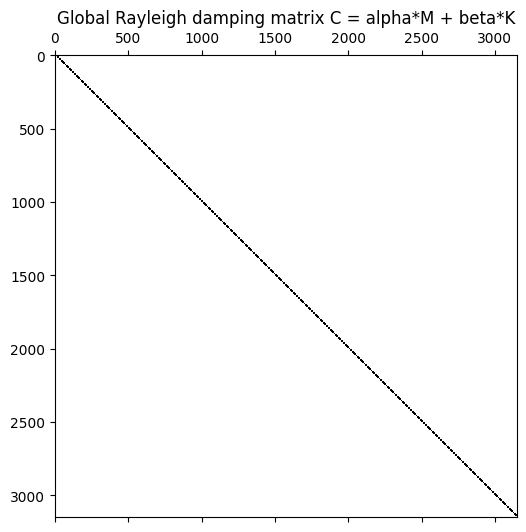

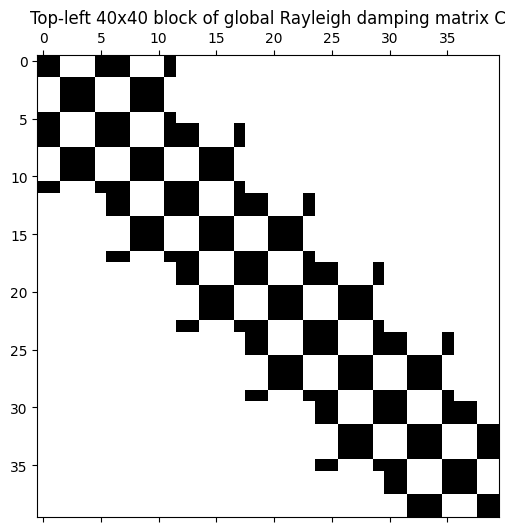

In [50]:
# Rayleigh damping settings
zeta_target = 0.03  # 3% critical damping; pas aan naar bijvoorbeeld 0.02 voor 2%
mode_i = 0          # eerste positieve mode
mode_j = 1          # tweede positieve mode

omega_i = w[mode_i]
omega_j = w[mode_j]

# Solve for alpha and beta from:
# zeta = 0.5*(alpha/omega + beta*omega)
A_rayleigh = np.array([
    [1/(2*omega_i), omega_i/2],
    [1/(2*omega_j), omega_j/2]
])
b_rayleigh = np.array([zeta_target, zeta_target])

alpha_rayleigh, beta_rayleigh = np.linalg.solve(A_rayleigh, b_rayleigh)

# Full global Rayleigh damping matrix and reduced free-DOF matrix
C_rayleigh = alpha_rayleigh*M + beta_rayleigh*K
C_FF = C_rayleigh[np.ix_(DofsF, DofsF)]

print('Rayleigh damping fitted on:')
print(f'  mode {mode_i}: f = {f[mode_i]:.6g} Hz, omega = {omega_i:.6g} rad/s')
print(f'  mode {mode_j}: f = {f[mode_j]:.6g} Hz, omega = {omega_j:.6g} rad/s')
print(f'  zeta_target = {zeta_target:.4f}')
print(f'alpha_rayleigh = {alpha_rayleigh:.6e}  [1/s]')
print(f'beta_rayleigh  = {beta_rayleigh:.6e}  [s]')
print('C_rayleigh shape:', C_rayleigh.shape)
print('C_FF shape:', C_FF.shape)

plt.figure()
plt.spy(C_rayleigh)
plt.title('Global Rayleigh damping matrix C = alpha*M + beta*K')

plt.figure()
plt.spy(C_rayleigh[:40, :40])
plt.title('Top-left 40x40 block of global Rayleigh damping matrix C')
pass

First 10 modal damping ratios:
Mode  0: f = 0.0242763 Hz, zeta = 0.0300
Mode  1: f = 0.0258412 Hz, zeta = 0.0300
Mode  2: f = 0.0296758 Hz, zeta = 0.0304
Mode  3: f = 0.0356883 Hz, zeta = 0.0319
Mode  4: f = 0.0435267 Hz, zeta = 0.0347
Mode  5: f = 0.0530533 Hz, zeta = 0.0388
Mode  6: f = 0.0596752 Hz, zeta = 0.0420
Mode  7: f = 0.0635528 Hz, zeta = 0.0440
Mode  8: f = 0.0704886 Hz, zeta = 0.0475
Mode  9: f = 0.0809076 Hz, zeta = 0.0531


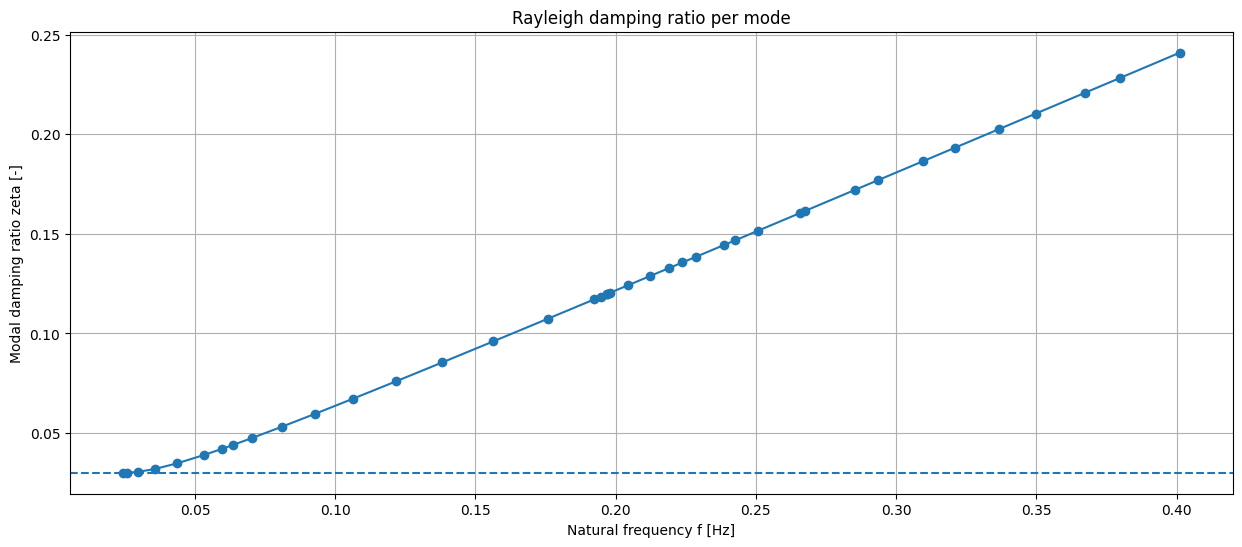

In [51]:
# Check the damping ratio that Rayleigh damping gives per mode
zeta_modes = 0.5*(alpha_rayleigh/w + beta_rayleigh*w)

plt.figure()
plt.plot(f[:40], zeta_modes[:40], marker='o')
plt.axhline(zeta_target, linestyle='--')
plt.xlabel('Natural frequency f [Hz]')
plt.ylabel('Modal damping ratio zeta [-]')
plt.title('Rayleigh damping ratio per mode')
plt.grid(True)

print('First 10 modal damping ratios:')
for i in range(min(10, len(f))):
    print(f'Mode {i:2d}: f = {f[i]:.6g} Hz, zeta = {zeta_modes[i]:.4f}')

In [52]:
# try:
#     import nbformat
# except ImportError:
#     import sys
#     import subprocess
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "nbformat"])
#     import nbformat
# %run nb02_j_morison.ipynb

# === Morison force time series ===
# Deze arrays komen uit de Morison-notebook:
# t_t   = tijdarray [s]
# Fx_t  = totale horizontale kracht per meter [N/m]
# Fz_t  = totale verticale kracht per meter [N/m]

# Als je de Morison-notebook eerst draait:
# %run nb02_j_morison.ipynb

t_force = np.asarray(t_t)
qx_force = np.asarray(Fx_t)   # N/m, horizontaal
qz_force = np.asarray(Fz_t)   # N/m, verticaal

# Daarna maak je een functie die per tijdstap de distributed load omzet
#  naar equivalente nodale krachten:

def assemble_morison_force(t, Ele, NodeC, nDof, LDOF, t_force, qx_force, qz_force):
    F = np.zeros(nDof)

    qx = np.interp(t, t_force, qx_force)  # N/m
    qz = np.interp(t, t_force, qz_force)  # N/m

    for iEle in range(nEle):
        n1, n2, *_ = Ele[iEle]
        n1 = int(round(n1))
        n2 = int(round(n2))

        x1 = np.array(NodeC[n1])
        x2 = np.array(NodeC[n2])
        L = np.linalg.norm(x2 - x1)

        # equivalente nodale krachten voor uniforme lijnlast
        # Fx -> globale x DOF
        F[n1*LDOF + 0] += qx * L / 2
        F[n2*LDOF + 0] += qx * L / 2

        # Fz -> globale z DOF
        F[n1*LDOF + 1] += (qz) * L / 2
        F[n2*LDOF + 1] += (qz) * L / 2

    return F

In [53]:
def assemble_static_pretension_force(Ele, NodeC, nDof, LDOF, q_pretension=648e3):
    """
    Assembleert constante opwaartse pretension als globale krachtvector.

    q_pretension: N/m
    positieve waarde = positieve z-richting
    """

    F = np.zeros(nDof)

    for iEle in range(nEle):
        n1, n2, *_ = Ele[iEle]
        n1 = int(round(n1))
        n2 = int(round(n2))

        x1 = np.array(NodeC[n1])
        x2 = np.array(NodeC[n2])
        L = np.linalg.norm(x2 - x1)

        F[n1*LDOF + 1] += q_pretension * L / 2
        F[n2*LDOF + 1] += q_pretension * L / 2

    return F

In [54]:


# ============================================================
# Dynamische oplossing met Newmark + statische pretension
# ============================================================

dt = t_force[1] - t_force[0]
t_dyn = np.arange(0, 120 + dt, dt)

nF = len(DofsF)

# ------------------------------------------------------------
# 1. Statische pretension kracht
# ------------------------------------------------------------

F_static = assemble_static_pretension_force(
    Ele, NodeC, nDof, LDOF, q_pretension=648e3
)

F_static_F = F_static[DofsF]

# Statisch evenwicht door pretension
u_static = np.linalg.solve(K_FF, F_static_F)

# ------------------------------------------------------------
# 2. Initialisatie
# ------------------------------------------------------------

u = np.zeros((len(t_dyn), nF))
v = np.zeros((len(t_dyn), nF))
a = np.zeros((len(t_dyn), nF))

# Start vanuit statisch evenwicht
u[0] = u_static
v[0] = 0.0

# Eerste dynamische kracht
F_dynamic0 = assemble_morison_force(
    t_dyn[0], Ele, NodeC, nDof, LDOF,
    t_force, qx_force, qz_force
)

F0 = F_static + F_dynamic0
F0_F = F0[DofsF]

# Eerste versnelling
a[0] = np.linalg.solve(
    M_FF,
    F0_F - C_FF @ v[0] - K_FF @ u[0]
)

# ------------------------------------------------------------
# 3. Newmark parameters
# ------------------------------------------------------------

beta = 1/4
gamma = 1/2

K_eff = (
    K_FF
    + gamma/(beta*dt) * C_FF
    + 1/(beta*dt**2) * M_FF
)

K_eff_inv = np.linalg.inv(K_eff)

# ------------------------------------------------------------
# 4. Tijdintegratie
# ------------------------------------------------------------

for i in range(1, len(t_dyn)):

    F_dynamic = assemble_morison_force(
        t_dyn[i], Ele, NodeC, nDof, LDOF,
        t_force, qx_force, qz_force
    )

    # Totale kracht = statisch + dynamisch
    F_total = F_static + F_dynamic
    F = F_total[DofsF]

    rhs = (
        F
        + M_FF @ (
            1/(beta*dt**2) * u[i-1]
            + 1/(beta*dt) * v[i-1]
            + (1/(2*beta) - 1) * a[i-1]
        )
        + C_FF @ (
            gamma/(beta*dt) * u[i-1]
            + (gamma/beta - 1) * v[i-1]
            + dt * (gamma/(2*beta) - 1) * a[i-1]
        )
    )

    u[i] = K_eff_inv @ rhs

    a[i] = (
        1/(beta*dt**2) * (u[i] - u[i-1])
        - 1/(beta*dt) * v[i-1]
        - (1/(2*beta) - 1) * a[i-1]
    )

    v[i] = v[i-1] + dt * ((1 - gamma) * a[i-1] + gamma * a[i])

# ------------------------------------------------------------
# 5. Terugzetten naar volledige globale verplaatsingsvector
# ------------------------------------------------------------

U_full = np.zeros((len(t_dyn), nDof))
U_full[:, DofsF] = u

Max |ux| = 0.18697092187187664 m
Max |uy| = 1.094747650233928 m  <-- vertical displacement
Max |uz| = 0.0 m  <-- out of plane


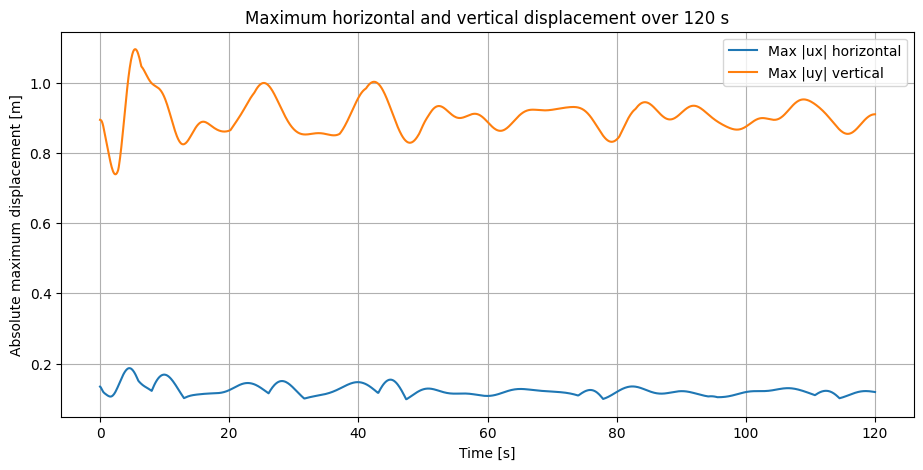

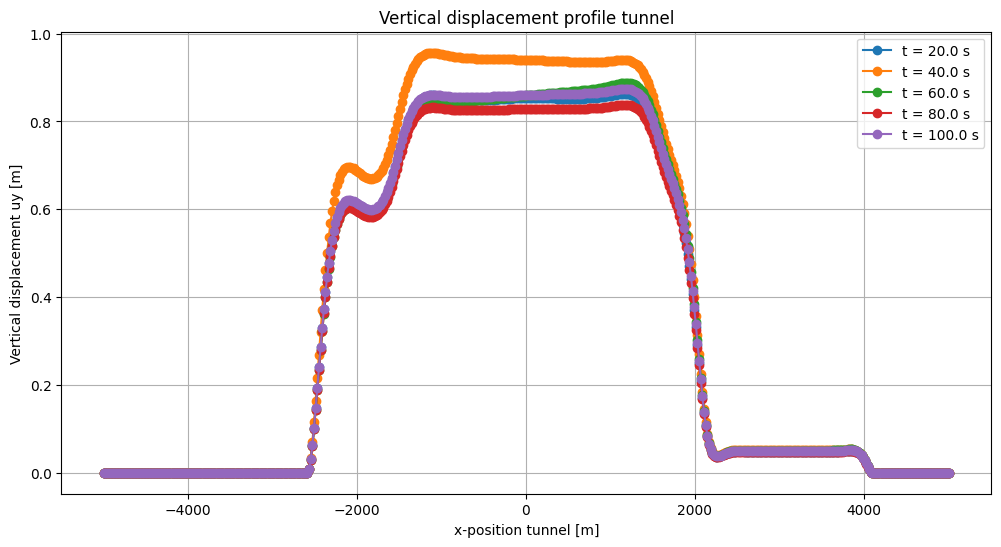

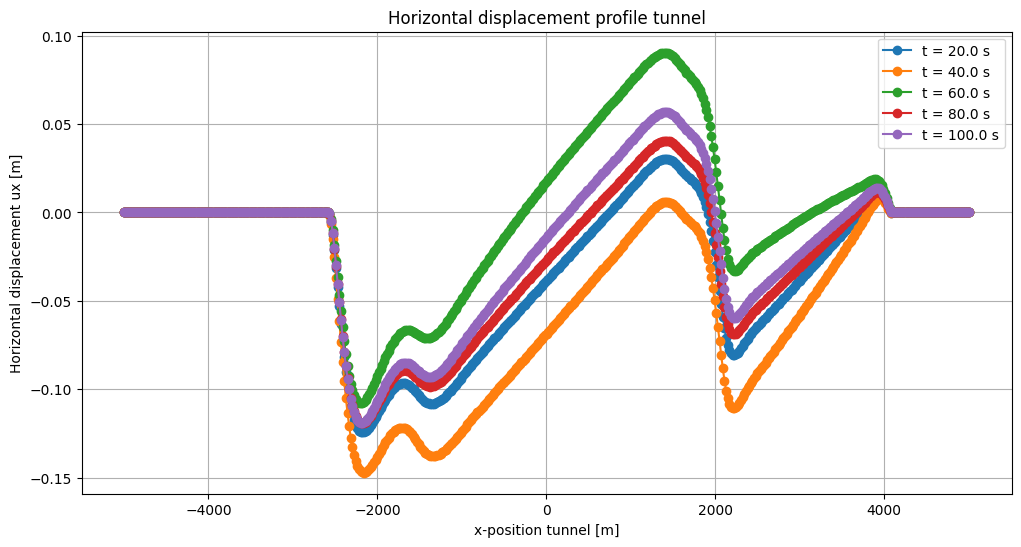

Selected nodes:
  x = -2000 m -> node 161, xnode = -2002.13 m
  x = -1000 m -> node 212, xnode = -994.03 m
  x = -500 m -> node 237, xnode = -495.44 m
  x = 0 m -> node 262, xnode = 4.40 m
  x = 500 m -> node 287, xnode = 504.22 m
  x = 1000 m -> node 312, xnode = 1002.78 m
  x = 2000 m -> node 362, xnode = 1991.15 m


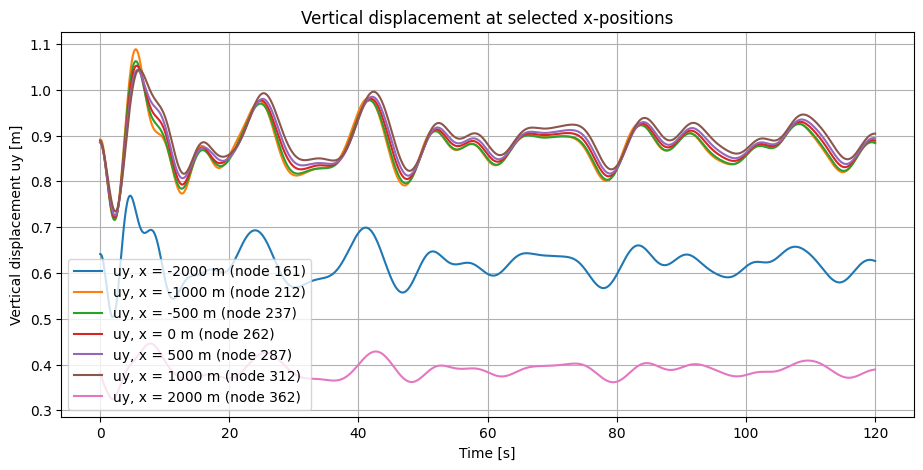

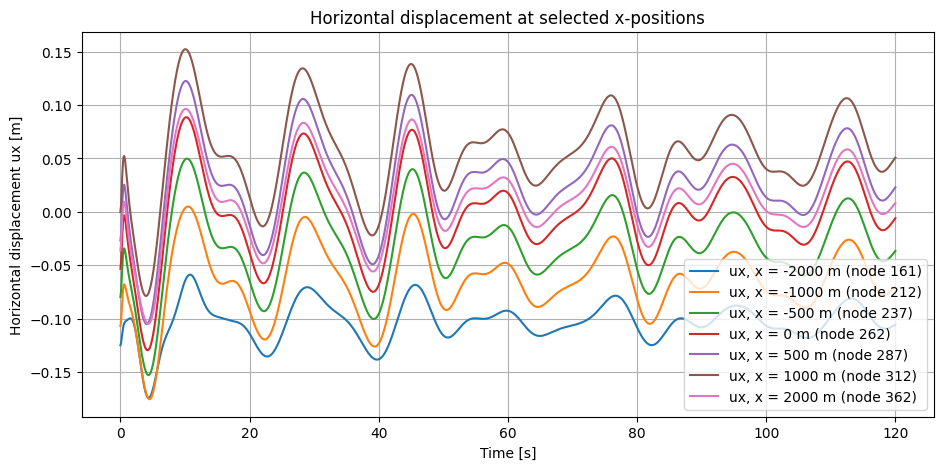

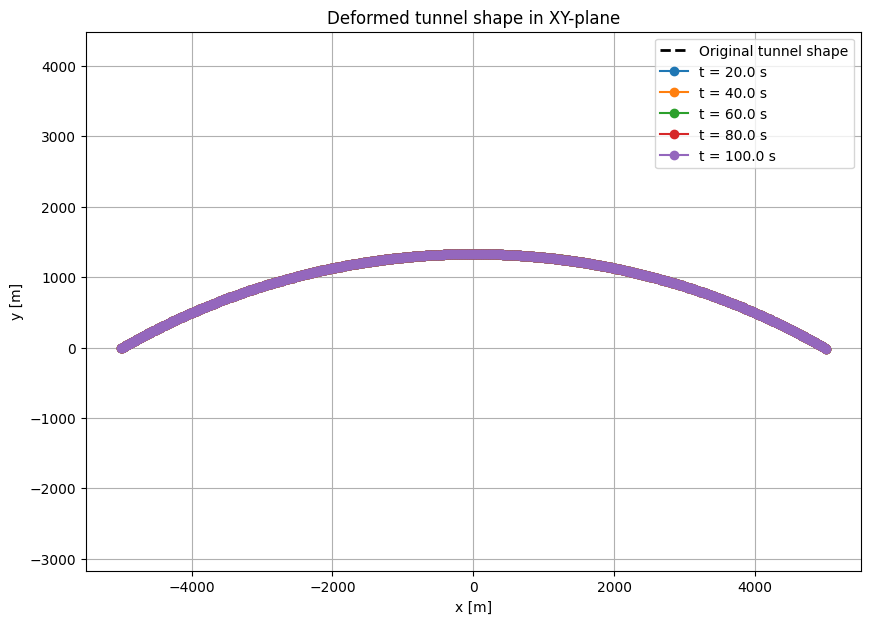

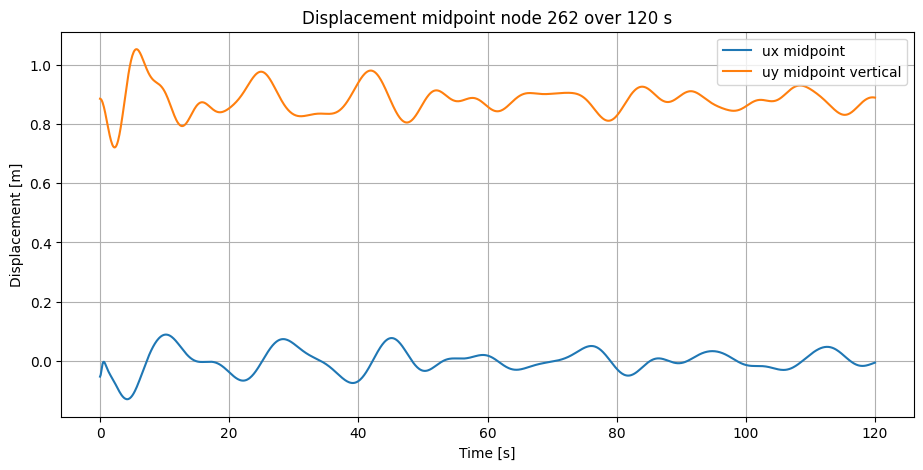

Middenpunt node: 262
x-positie: 4.398229573033409 m
y-positie: 1329.1465746344384 m
Max |ux middenpunt|: 0.1297176391675073 m
Max |uy middenpunt|: 1.0527190062732439 m


In [55]:
# ============================================================
# Correct plot cell for your system
# Tunnel lies in XY-plane:
# ux = x-direction
# uy = vertical direction in the tunnel plane
# uz = out-of-plane direction
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

NodeC = np.asarray(NodeC)

nNode = NodeC.shape[0]
xnodes = NodeC[:, 0]
ynodes = NodeC[:, 1]

# DOF order per node:
# [ux, uy, uz, rx, ry, rz]
ux_all = U_full[:, 0::LDOF]   # horizontal / x-direction
uy_all = U_full[:, 1::LDOF]   # vertical / y-direction
uz_all = U_full[:, 2::LDOF]   # out-of-plane / z-direction

# ============================================================
# 1. Check maximum displacements per direction
# ============================================================

print("Max |ux| =", np.max(np.abs(ux_all)), "m")
print("Max |uy| =", np.max(np.abs(uy_all)), "m  <-- vertical displacement")
print("Max |uz| =", np.max(np.abs(uz_all)), "m  <-- out of plane")

# ============================================================
# 2. Absolute maximum horizontal and vertical displacement
# ============================================================

ux_max_abs_t = np.max(np.abs(ux_all), axis=1)
uy_max_abs_t = np.max(np.abs(uy_all), axis=1)

plt.figure(figsize=(11,5))
plt.plot(t_dyn, ux_max_abs_t, label="Max |ux| horizontal")
plt.plot(t_dyn, uy_max_abs_t, label="Max |uy| vertical")

plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Absolute maximum displacement [m]")
plt.title("Maximum horizontal and vertical displacement over 120 s")
plt.legend()
plt.show()

# ============================================================
# 3. Vertical displacement profile uy at 20, 40, 60, 80, 100 s
# ============================================================

plot_times = [20, 40, 60, 80, 100]

plt.figure(figsize=(12,6))

for tp in plot_times:
    it = np.argmin(np.abs(t_dyn - tp))
    plt.plot(
        xnodes,
        uy_all[it, :],
        marker="o",
        label=f"t = {t_dyn[it]:.1f} s"
    )

plt.grid(True)
plt.xlabel("x-position tunnel [m]")
plt.ylabel("Vertical displacement uy [m]")
plt.title("Vertical displacement profile tunnel")
plt.legend()
plt.show()

# ============================================================
# 4. Horizontal displacement profile ux at 20, 40, 60, 80, 100 s
# ============================================================

plt.figure(figsize=(12,6))

for tp in plot_times:
    it = np.argmin(np.abs(t_dyn - tp))
    plt.plot(
        xnodes,
        ux_all[it, :],
        marker="o",
        label=f"t = {t_dyn[it]:.1f} s"
    )

plt.grid(True)
plt.xlabel("x-position tunnel [m]")
plt.ylabel("Horizontal displacement ux [m]")
plt.title("Horizontal displacement profile tunnel")
plt.legend()
plt.show()

# ============================================================
# 5. Displacement at specific x-locations
# ============================================================

selected_x = [-2000, -1000, -500, 0, 500, 1000, 2000]  # m
selected_nodes = [np.argmin(np.abs(xnodes - xval)) for xval in selected_x]
print("Selected nodes:")
for xval, inode in zip(selected_x, selected_nodes):
    print(f"  x = {xval} m -> node {inode}, xnode = {xnodes[inode]:.2f} m")

plt.figure(figsize=(11,5))
for xval, inode in zip(selected_x, selected_nodes):
    plt.plot(
        t_dyn,
        uy_all[:, inode],
        label=f"uy, x = {xval} m (node {inode})"
    )

plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Vertical displacement uy [m]")
plt.title("Vertical displacement at selected x-positions")
plt.legend()
plt.show()

plt.figure(figsize=(11,5))
for xval, inode in zip(selected_x, selected_nodes):
    plt.plot(
        t_dyn,
        ux_all[:, inode],
        label=f"ux, x = {xval} m (node {inode})"
    )

plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Horizontal displacement ux [m]")
plt.title("Horizontal displacement at selected x-positions")
plt.legend()
plt.show()

# ============================================================
# 6. Deformed tunnel shape in XY-plane at selected times
# ============================================================

scale = 1.0   # optionally increase/decrease for visibility

plt.figure(figsize=(10,7))

plt.plot(
    xnodes,
    ynodes,
    "k--",
    linewidth=2,
    label="Original tunnel shape"
)

for tp in plot_times:
    it = np.argmin(np.abs(t_dyn - tp))

    x_def = xnodes + scale * ux_all[it, :]
    y_def = ynodes + scale * uy_all[it, :]

    plt.plot(
        x_def,
        y_def,
        marker="o",
        label=f"t = {t_dyn[it]:.1f} s"
    )

plt.axis("equal")
plt.grid(True)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Deformed tunnel shape in XY-plane")
plt.legend()
plt.show()

# ============================================================
# 7. Displacement of the midpoint over 120 seconds
# ============================================================

x_mid = 0.5 * (np.min(xnodes) + np.max(xnodes))
node_mid = np.argmin(np.abs(xnodes - x_mid))

ux_mid = ux_all[:, node_mid]
uy_mid = uy_all[:, node_mid]

plt.figure(figsize=(11,5))
plt.plot(t_dyn, ux_mid, label="ux midpoint")
plt.plot(t_dyn, uy_mid, label="uy midpoint vertical")

plt.grid(True)
plt.xlabel("Time [s]")
plt.ylabel("Displacement [m]")
plt.title(f"Displacement midpoint node {node_mid} over 120 s")
plt.legend()
plt.show()

print("Middenpunt node:", node_mid)
print("x-positie:", xnodes[node_mid], "m")
print("y-positie:", ynodes[node_mid], "m")
print("Max |ux middenpunt|:", np.max(np.abs(ux_mid)), "m")
print("Max |uy middenpunt|:", np.max(np.abs(uy_mid)), "m")

## Gebruik in dynamische analyse

Gebruik vanaf hier in je bewegingsvergelijking:

$$ M_{FF}\ddot{u} + C_{FF}\dot{u} + K_{FF}u = F_{FF}(t) $$

Dus voor de vrije vrijheidsgraden gebruik je:

- `M_FF`
- `C_FF`
- `K_FF`

`C_element` blijft bewaard als controle, maar de echte demping in deze notebook is `C_rayleigh`.

In [56]:
nMode = len(f)
print(nMode)
ModalShape = np.zeros((nDof, nMode))
ModalShape[DofsF, :] = vr

1863
